## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health?

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from sklearn.preprocessing import StandardScaler

## 1.

In [23]:
df = pd.read_csv('golub.csv')

mapper = {'allB': 0, 'allT': 0, 'aml': 1} #relable
df['outcome'] = df['cancer'].map(mapper)

df[['Samples', 'cancer', 'outcome']].head()

,Samples,cancer,outcome
0,39,allB,0
1,40,allB,0
2,42,allB,0
3,47,allB,0
4,48,allB,0


In [24]:
y = df['outcome'] #target variable
X = df.drop(['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer', 'outcome'], axis=1) #remove variables not using

print(f'Observations: {X.shape[0]}')
print(f'Predictors (genes used): {X.shape[1]}')

Observations: 72
Predictors (genes used): 7129


##2.

In [25]:
mse = lambda y_true, y_pred: np.mean((y_true - y_pred) ** 2)

ols = LinearRegression().fit(X, y)
y_hat_ols = ols.predict(X)
residuals_ols = y_hat_ols - y

print(f'OLS training MSE: {mse(y, y_hat_ols):.6g}')


OLS training MSE: 1.54109e-30


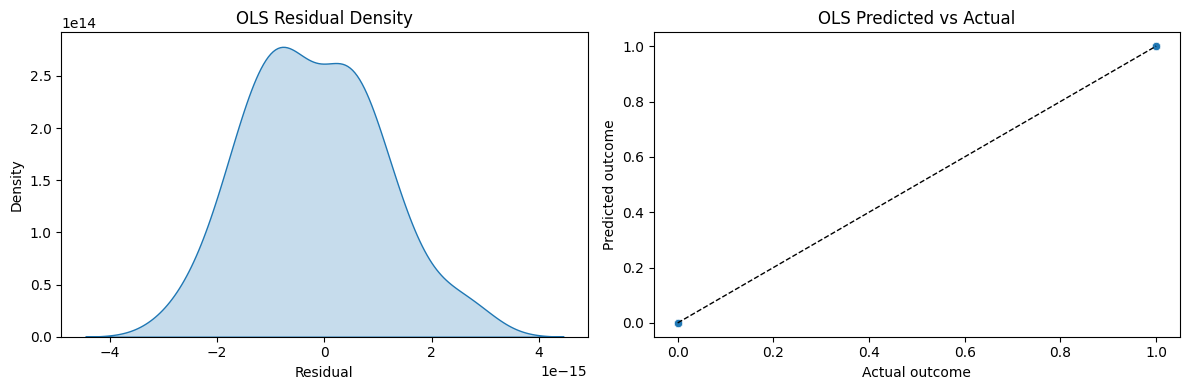

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(residuals_ols, fill=True, ax=axes[0])
axes[0].set_title('OLS Residual Density')
axes[0].set_xlabel('Residual')

sns.scatterplot(x=y, y=y_hat_ols, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
axes[1].set_title('OLS Predicted vs Actual')
axes[1].set_xlabel('Actual outcome')
axes[1].set_ylabel('Predicted outcome')

plt.tight_layout()
plt.show()

The training MSE is very close to zero, indicating that the linear model estimates the testing data very well. The data has more gene predictions than patient observations, so the linear model is able to match the sample very well, given that it is unregulized and does not add a penalty to restrict the size of coefficients to reduce the variance and prevent overfitting.

##3.

In [27]:
kfold = KFold(n_splits=5, shuffle=True, random_state=100)
cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=kfold,
    scoring='neg_mean_squared_error'
)
cv_mse = -cv_scores

print('Fold MSE values:', cv_mse)
print(f'Mean CV MSE: {cv_mse.mean():.6f}')
print(f'Median CV MSE: {np.median(cv_mse):.6f}')
print(f'Standard deviation: {cv_mse.std():.6f}')

Fold MSE values: [0.0244198  0.05792023 0.09224999 0.02097934 0.02126042]
Mean CV MSE: 0.043366
Median CV MSE: 0.024420
Standard deviation: 0.028108


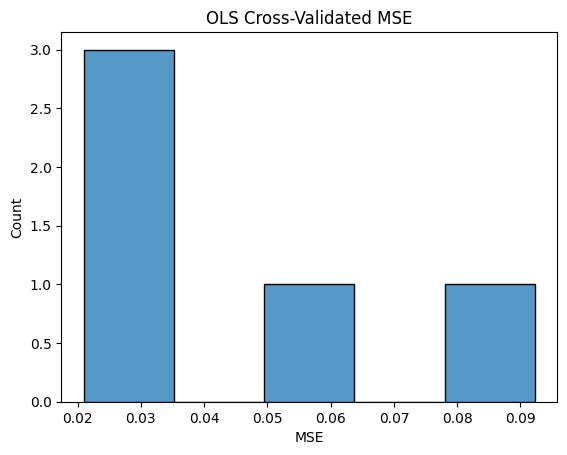

In [28]:
sns.histplot(cv_mse, bins=5)
plt.title('OLS Cross-Validated MSE')
plt.xlabel('MSE')
plt.show()

The mean square error of the linear model with cross validation indicates that the training model with OLS is overfitting, as it is fitting many genes to only a few patients, creating high variance and low bias in the bias variance trade-off and making it hard to generalize to testing data. This can be seen through the MSE values that are all much higher with cross validation than they are for the training model.

##4.

In [29]:
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

alphas = np.logspace(-4, -2, num=50)
lasso_cv = LassoCV(cv=10, alphas=alphas, random_state=100, max_iter=10000)
lasso_cv.fit(X_sc, y)

alpha_star = lasso_cv.alpha_
mean_mse_path = np.mean(lasso_cv.mse_path_, axis=1)
index_star = np.argmin(mean_mse_path)

coefs = []
for alpha in lasso_cv.alphas_:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_sc, y)
    coefs.append(model.coef_)
coefs = np.array(coefs)

coefs_star = coefs[index_star]
selected_idx = np.nonzero(coefs_star)[0]
selected_genes = X.columns[selected_idx].tolist()

lasso_star = Lasso(alpha=alpha_star, max_iter=10000).fit(X_sc, y)
y_hat_lasso = lasso_star.predict(X_sc)

print(f'Optimal alpha: {alpha_star:.10f}')
print(f'Selected genes: {len(selected_genes)}')
print(f'Discarded genes: {X.shape[1] - len(selected_genes)}')
selected_genes

Optimal alpha: 0.0006551286
Selected genes: 80
Discarded genes: 7049


['AF000560_at',
 'AF002020_at',
 'AF006087_at',
 'D26579_at',
 'D29956_at',
 'D42043_at',
 'D50840_at',
 'D86982_at',
 'HG2161-HT2231_at',
 'J04101_at',
 'J04164_at',
 'L12723_at',
 'L13848_at',
 'L20941_at',
 'M12759_at',
 'M17754_at',
 'M19507_at',
 'M20902_at',
 'M22960_at',
 'M23197_at',
 'M27891_at',
 'M28713_at',
 'M31994_at',
 'M63138_at',
 'M84526_at',
 'M95178_at',
 'M96326_rna1_at',
 'M98539_at',
 'U10868_at',
 'U14588_at',
 'U30828_at',
 'U34877_at',
 'U36621_cds2_at',
 'U46751_at',
 'U50136_rna1_at',
 'U51127_at',
 'U60062_at',
 'U82313_at',
 'U82759_at',
 'U88666_at',
 'U89942_at',
 'X04143_at',
 'X14789_at',
 'X16706_at',
 'X53331_at',
 'X56741_at',
 'X63753_at',
 'X66533_at',
 'X66867_cds1_at',
 'X69111_at',
 'X81479_at',
 'X83378_at',
 'X95735_at',
 'X96698_at',
 'Y00636_at',
 'Y07604_at',
 'Y07755_at',
 'Y10207_at',
 'Y12670_at',
 'M96843_at',
 'X58072_at',
 'AC002477_s_at',
 'L15326_s_at',
 'X57351_at',
 'K02777_s_at',
 'U37055_rna1_s_at',
 'U59632_s_at',
 'X07438_s_a

There are 80 genes that are selected  by the LASSO. The genes that are 'AF000560_at',
 'AF002020_at',
 'AF006087_at',
 'D26579_at',
 'D29956_at',
 'D42043_at',
 'D50840_at',
 'D86982_at',
 'HG2161-HT2231_at',
 'J04101_at',
 'J04164_at',
 'L12723_at',
 'L13848_at',
 'L20941_at',
 'M12759_at',
 'M17754_at',
 'M19507_at',
 'M20902_at',
 'M22960_at',
 'M23197_at',
 'M27891_at',
 'M28713_at',
 'M31994_at',
 'M63138_at',
 'M84526_at',
 'M95178_at',
 'M96326_rna1_at',
 'M98539_at',
 'U10868_at',
 'U14588_at',
 'U30828_at',
 'U34877_at',
 'U36621_cds2_at',
 'U46751_at',
 'U50136_rna1_at',
 'U51127_at',
 'U60062_at',
 'U82313_at',
 'U82759_at',
 'U88666_at',
 'U89942_at',
 'X04143_at',
 'X14789_at',
 'X16706_at',
 'X53331_at',
 'X56741_at',
 'X63753_at',
 'X66533_at',
 'X66867_cds1_at',
 'X69111_at',
 'X81479_at',
 'X83378_at',
 'X95735_at',
 'X96698_at',
 'Y00636_at',
 'Y07604_at',
 'Y07755_at',
 'Y10207_at',
 'Y12670_at',
 'M96843_at',
 'X58072_at',
 'AC002477_s_at',
 'L15326_s_at',
 'X57351_at',
 'K02777_s_at',
 'U37055_rna1_s_at',
 'U59632_s_at',
 'X07438_s_at',
 'M12959_s_at',
 'M13690_s_at',
 'M26708_s_at',
 'M84371_rna1_s_at',
 'X12876_s_at',
 'M31211_s_at',
 'U26312_s_at',
 'X85116_rna1_s_at',
 'HG4518-HT4921_r_at',
 'L08010_at',
 'U84388_at',
 'X06318_at'. There are also 7049 discarded genes.

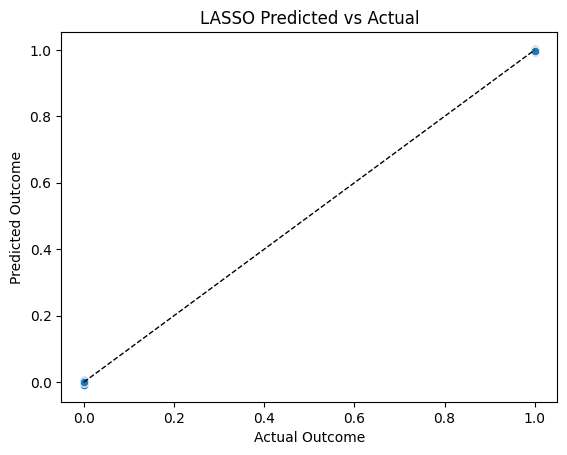

LASSO training MSE: 7.33671e-06


In [32]:
#scatterplot of predicted and actual values
sns.scatterplot(x=y, y=y_hat_lasso)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
plt.title('LASSO Predicted vs Actual')
plt.xlabel('Actual Outcome')
plt.ylabel('Predicted Outcome')
plt.show()

print(f'LASSO training MSE: {mse(y, y_hat_lasso):.6g}')

##5.

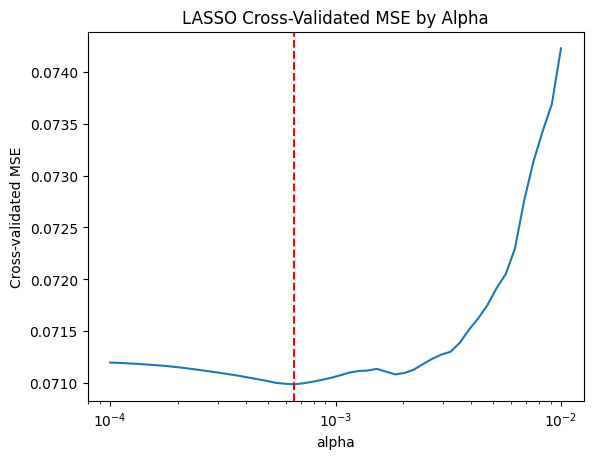

In [35]:
sns.lineplot(x=lasso_cv.alphas_, y=mean_mse_path)
plt.axvline(alpha_star, color='red', linestyle='--', linewidth=1.5)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Cross-validated MSE')
plt.title('LASSO Cross-Validated MSE by Alpha')
plt.show()

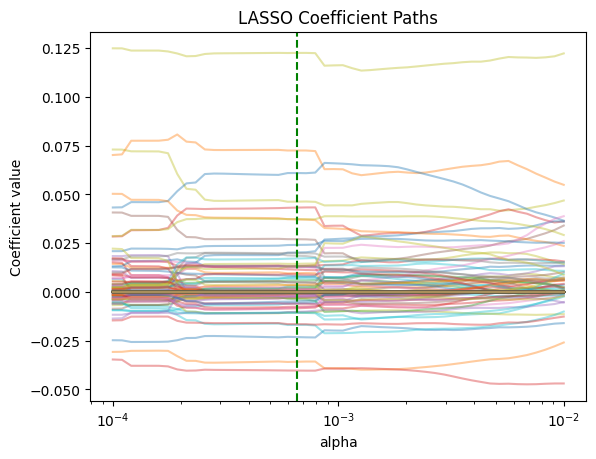

In [36]:
for i in range(coefs.shape[1]):
    plt.plot(lasso_cv.alphas_, coefs[:, i], alpha=0.4)
plt.xscale('log')
plt.axvline(alpha_star, color='green', linestyle='--')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('LASSO Coefficient Paths')
plt.show()

As the alpha value increases, so does the cross-validated MSE. This means that when the alpha value is smaller and lower than the minimum value, the model is underfitting because it is using too few coefficients. On the right side of the plot, above the minimum MSE, the model is overfitting because it is using too many coefficiencts. The minimum is where the model has the least MSE at around .0006551286.

##6.

Linear regression performs perfectly on the training set because it uses a very small amount of samples, or patients, with a very large set of genes, or predictors, so the model is able to match very closely to the sample and "memorize" it. This means the training error is very low but the coefficients very sensitive to noise.

The LASSO provides a better predictive performance because it reduces the amount of coefficients and makes many of them 0, which greatly reduces variance, even though it does raise bias slightly in the bias variance trade-off. In this case, only a small subset of genes carry most of the predictive power, as many of the genes were discarded, so the trade-off for the variance is helpful.

##7.

Regularization methods lend themselves to scenarios like precision health because there are so many variables that can be used in health to measure outcomes, such as the number of genes that are used in this lab alone. These methods are able to select the genes, or other predictors, that are most impactful so it is possible to study the impacts of certain genes in research without having an incredible expansive set of variables that makes studying them impossible.

##8.

The risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health are that if one is narrowing down the set of genes and interactions, they may be missing out on one that actually does play a significant role but was missed out on, and may not be doing the full analysis that could provide extra insight. This could provide risks to patients when we may be missing something when trying to optimize patient health.

Additionally, while some genes may have a strong predictive value, this does not necessarily mean that they have a direct impact on health, and may just be correlation. This is especially true because we only observe genes, and cannot alter them to see their effects. It is important that we are aware of this when making medical decisions that impact people and only know the correlation of variables, not the causation or direct impact.